# Supplementary Figure SR3 — directional concordance by MAF bin

Mean directional concordance with 95% confidence intervals across MAF bins, over the pleiotropic
clusters only. Concordance is the largest share of same-direction effects for a variant, so it is 1
for a variant associated with a single disease; the trend with MAF is the observation Supplementary
Results 6 draws on.

**Rebuilt on the current concordance protocol.** The quantity is now
`signedLeadDirectionalConcordance` and the universe is `signedLeadVPS > 1`, both taken from the
cluster's representative lead variant. A credible set contributes only if the variant is its lead
variant, its study maps to exactly one disease term, and its `directionOfEffect` is known; direction
comes from the harmonised effect-allele beta with no minor-allele conversion, and the most
significant contributing study wins per disease. Because every counted disease is signed by
construction, concordance is defined for every variant in the universe — there is no missing-value
group inside the plot. See `chapters/01-data-preparation/07_variant_features.ipynb` and
`chapters/02-analysis-main/README.md`.

This replaces the published quantity, which was `betaSignConcordance` over every credible set of the
variant with direction taken from `rescaledStatistics.minorAlleleEstimatedBeta`, on the
`uniqueDiseases > 1` universe (the filter the published figure used:
`chapters/_legacy/03-manuscript-figures/figure_3/python_scripts/clustering_analysis.ipynb`, cell 40,
`cluster_pleiotropy.filter(uniqueDiseases > 1)`). Both earlier readings are computed below for
comparison, so the figure can be moved back if the section keeps the published definition.

Writes `figure_sr3.pdf`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from manuscript_methods import paper

FIGURE_DIR = paper.ROOT / "chapters" / "05-figures-supplementary" / "supplementary"
MAF_BINS = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
MAF_BIN_LABELS = ["0-0.01", "0.01-0.05", "0.05-0.1", "0.1-0.2", "0.2-0.3", "0.3-0.4", "0.4-0.5"]

clusters = pd.read_parquet(paper.derived("cluster_covariates"))
clusters["maxMAF_bin"] = pd.cut(clusters["maxMAF"], bins=MAF_BINS, labels=MAF_BIN_LABELS, right=False)
assert len(clusters) == 20041, len(clusters)
print(f"clusters: {len(clusters):,}")

clusters: 20,041


## Mean concordance per MAF bin

In [2]:
CONCORDANCE = "signedLeadDirectionalConcordance"
VPS = "signedLeadVPS"

pleiotropic = clusters[clusters["signedLeadVPSDefined"] & (clusters[VPS] > 1)]
# No missing values inside the universe: a disease with no directional information never enters the
# score, so a variant either has a concordance or is excluded from the universe altogether.
assert pleiotropic[CONCORDANCE].notna().all()

summary = pleiotropic.groupby("maxMAF_bin", observed=False)[CONCORDANCE].agg(["count", "mean", "sem"]).reset_index()
summary["ci"] = summary["sem"] * 1.96
print(f"pleiotropic clusters: {len(pleiotropic):,} of {len(clusters):,}")
print(f"excluded, nothing contributes: {int((~clusters['signedLeadVPSDefined']).sum()):,}")
print(summary.round(5).to_string(index=False))

pleiotropic clusters: 2,166 of 20,041
excluded, nothing contributes: 3,019
maxMAF_bin  count    mean     sem      ci
    0-0.01    106 0.96994 0.01027 0.02013
 0.01-0.05    274 0.96757 0.00644 0.01262
  0.05-0.1    191 0.96163 0.00852 0.01671
   0.1-0.2    338 0.94515 0.00791 0.01551
   0.2-0.3    387 0.94508 0.00720 0.01410
   0.3-0.4    399 0.93041 0.00793 0.01555
   0.4-0.5    471 0.93306 0.00727 0.01426


## The figure

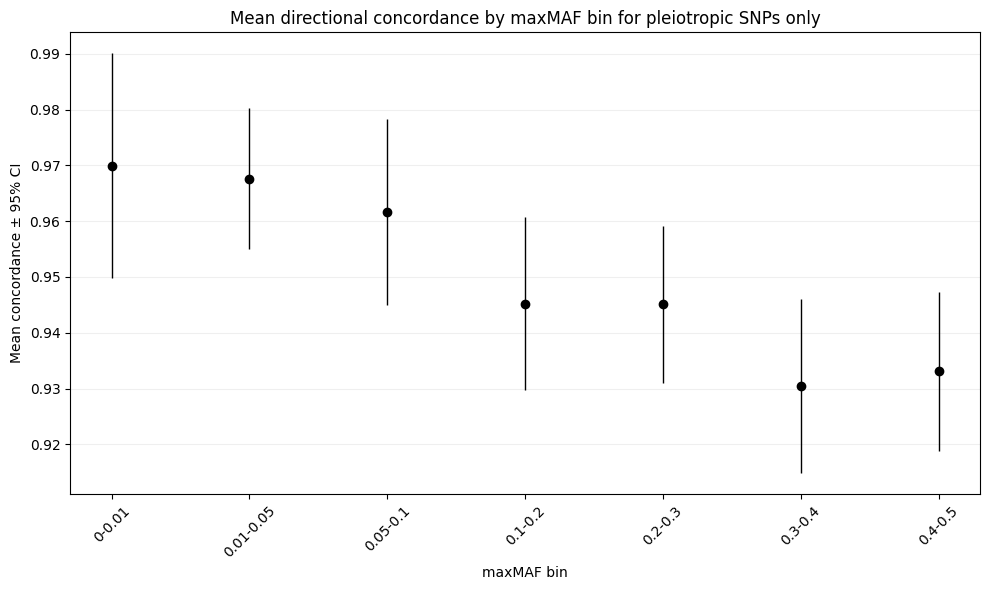

saved figure_sr3.pdf


In [3]:
plt.figure(figsize=(10, 6))
plt.errorbar(
    x=summary["maxMAF_bin"].astype(str),
    y=summary["mean"],
    yerr=summary["ci"],
    fmt="o",
    color="black",
    ecolor="black",
    capsize=0,
    elinewidth=1,
)
plt.title("Mean directional concordance by maxMAF bin for pleiotropic SNPs only")
plt.xlabel("maxMAF bin")
plt.ylabel("Mean concordance ± 95% CI")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="-", alpha=0.2)
plt.tight_layout()
plt.gcf().savefig(FIGURE_DIR / "figure_sr3.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("saved figure_sr3.pdf")

In [4]:
# The two earlier readings, on the same clusters and the same bins, so the figure can be moved
# back if the section keeps the published definition.
readings = [
    ("published: uniqueDiseases > 1, betaSignConcordance", clusters["uniqueDiseases"] > 1, "betaSignConcordance"),
    (
        "first redefinition: leadVPS > 1, leadDirectionalConcordance",
        clusters["leadVPS"] > 1,
        "leadDirectionalConcordance",
    ),
    ("current protocol: signedLeadVPS > 1, signedLeadDirectionalConcordance", clusters[VPS] > 1, CONCORDANCE),
]
for label, mask, column in readings:
    subset = clusters[mask & clusters[column].notna()]
    table = subset.groupby("maxMAF_bin", observed=False)[column].agg(["count", "mean"]).round(4)
    print(f"\n{label} — {len(subset):,} clusters with a value")
    print(table.to_string())


published: uniqueDiseases > 1, betaSignConcordance — 3,457 clusters with a value
            count    mean
maxMAF_bin               
0-0.01        135  0.9799
0.01-0.05     413  0.9787
0.05-0.1      322  0.9774
0.1-0.2       584  0.9703
0.2-0.3       613  0.9650
0.3-0.4       657  0.9529
0.4-0.5       733  0.9393

first redefinition: leadVPS > 1, leadDirectionalConcordance — 2,081 clusters with a value
            count    mean
maxMAF_bin               
0-0.01        105  0.9697
0.01-0.05     271  0.9668
0.05-0.1      183  0.9600
0.1-0.2       326  0.9494
0.2-0.3       373  0.9451
0.3-0.4       380  0.9288
0.4-0.5       443  0.9324

current protocol: signedLeadVPS > 1, signedLeadDirectionalConcordance — 2,166 clusters with a value
            count    mean
maxMAF_bin               
0-0.01        106  0.9699
0.01-0.05     274  0.9676
0.05-0.1      191  0.9616
0.1-0.2       338  0.9452
0.2-0.3       387  0.9451
0.3-0.4       399  0.9304
0.4-0.5       471  0.9331


The published PNG (`figures/figure_sr3.png`) plots the superseded quantity, so this figure is **not**
expected to match it and no pixel comparison is meaningful. The two differences to know about:

- The universe is smaller — 2,166 pleiotropic clusters against the 3,983 the published filter
  selects, of which only 3,457 carried a `betaSignConcordance` value at all.
- **The decline flattens at the top.** Under the published reading the highest-MAF bin has the
  lowest mean concordance, which is what the section's argument rests on. Under the current protocol
  the 0.3-0.4 bin sits slightly *below* the 0.4-0.5 bin (0.9304 against 0.9331), so concordance no
  longer falls monotonically with MAF. The two point estimates are well inside each other's
  intervals — [0.915, 0.946] against [0.919, 0.947] — so this is a flattening, **not a significant
  reversal**; the ordering of the last two bins should not be read as a finding either way. The
  decline over the first five bins is intact and steeper than published (0.9699 to 0.9452 against
  0.9799 to 0.9703). The sentence "The proportion of variants with discordant effects increased with
  MAF" still holds in direction but should not claim monotonicity to the top bin.

Both earlier readings are printed above so the choice is visible rather than buried in the figure.